# Step 55b — Clean 12-step template: dispersion vs daily_zpnl

Purpose: the single-feature regression workflow laid out strictly step by step, three
stages (Build -> Is it real? -> Trading rule), one markdown + one code cell per step.
`55a` stays as the exploratory bridge; this notebook is the clean template that `55c`
(feature pairs) will extend.

- Data: `54c_trade_log_with_features.csv`, daily aggregation (`daily_zpnl` = sum of `zpnl`,
  `dispersion` = first value that day, already lagged 1 day at build time).
- Split: chronological 70/30. Fit/selection uses TRAIN only; TEST is the final exam.
- Every number below is asserted against `55a` Sections 9-13 (to printed precision).
- Run with the memlabs folder as working directory (relative CSV path).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.style.use('dark_background')

FEATURE = 'dispersion'

def chk(name, val, ref, tol):
    assert abs(val - ref) <= tol, f'55a MISMATCH on {name}: got {val!r}, 55a ref {ref!r} (tol {tol})'
    print(f'  [assert OK vs 55a] {name} = {val:.6f}')

def zpf(z):
    pos = z[z > 0].sum(); neg = z[z < 0].sum()
    return pos / abs(neg) if neg != 0 else np.nan

trades = pd.read_csv('54c_trade_log_with_features.csv', parse_dates=['signal_dt'])
trades['date'] = trades['signal_dt'].dt.date
daily = trades.groupby('date').agg(daily_zpnl=('zpnl', 'sum'), dispersion=('dispersion', 'first')).reset_index()
daily = daily.dropna(subset=[FEATURE, 'daily_zpnl']).sort_values('date').reset_index(drop=True)
n = len(daily)

split_idx = int(n * 0.70)
train, test = daily.iloc[:split_idx], daily.iloc[split_idx:]
x_tr, y_tr = train[FEATURE].values.astype(float), train['daily_zpnl'].values.astype(float)
x_te, y_te = test[FEATURE].values.astype(float), test['daily_zpnl'].values.astype(float)
n_train, n_test = len(train), len(test)

print(f'n = {n} days   TRAIN n={n_train} ({train.date.min()} -> {train.date.max()})   '
      f'TEST n={n_test} ({test.date.min()} -> {test.date.max()})')
assert n_train == 1747 and n in (2496, 2497), f'unexpected sample size n={n}, n_train={n_train}'


n = 2497 days   TRAIN n=1747 (2015-02-04 -> 2023-04-11)   TEST n=750 (2023-04-12 -> 2026-08-31)


# STAGE 1 — BUILD (steps 1-4)

## Step 1 — Fit w, b (TRAIN)

w = Sxy / Sxx,  b = ȳ − w·x̄   where Sxx = Σ(x−x̄)², Sxy = Σ(x−x̄)(y−ȳ).

Plain English: the straight line through the TRAIN scatter that minimises squared error.
**Sample: TRAIN.**

In [2]:
Sxx_tr = np.sum((x_tr - x_tr.mean())**2)
Sxy_tr = np.sum((x_tr - x_tr.mean()) * (y_tr - y_tr.mean()))
w_tr = Sxy_tr / Sxx_tr
b_tr = y_tr.mean() - w_tr * x_tr.mean()
print(f'Sxx={Sxx_tr:.4f}  Sxy={Sxy_tr:.4f}')
print(f'w = {w_tr:.6f}   b = {b_tr:.4f}')
chk('w', w_tr, 1.154600, 5e-7)
chk('b', b_tr, -2.2046, 5e-5)


Sxx=906.1571  Sxy=1046.2494
w = 1.154600   b = -2.2046
  [assert OK vs 55a] w = 1.154600
  [assert OK vs 55a] b = -2.204593


## Step 2 — Predictions ŷ and residuals (TRAIN)

ŷ = b + w·x,  e = y − ŷ.

Plain English: what the line predicts for each TRAIN day, and how far off it is.
**Sample: TRAIN.**

In [3]:
yhat_tr = b_tr + w_tr * x_tr
resid_tr = y_tr - yhat_tr
print(f'mean residual = {resid_tr.mean():.2e} (should be ~0 by construction)')
print(f'residual std  = {resid_tr.std(ddof=1):.4f}')
assert abs(resid_tr.mean()) < 1e-8


mean residual = -4.23e-16 (should be ~0 by construction)
residual std  = 13.9496


## Step 3 — SSE (TRAIN)

SSE = Σ eᵢ².

Plain English: total squared miss of the line on TRAIN — the quantity OLS minimises.
**Sample: TRAIN.**

In [4]:
SSE_tr = np.sum(resid_tr**2)
print(f'SSE (TRAIN) = {SSE_tr:.2f}')


SSE (TRAIN) = 339754.20


## Step 4 — R² in-sample (TRAIN) and OOS R² (TEST)

R²_in = 1 − SSE / Σ(y−ȳ_train)²   (TRAIN).
R²_oos = 1 − Σ(y_test − ŷ_test)² / Σ(y_test − ȳ_**train**)²   (TEST; the baseline is the TRAIN mean,
because that is all you would have known in real time).

Plain English: how much variance the line explains on data it was fit on, vs on data it has
never seen. OOS R² > 0 means the line beats "just predict the TRAIN average".
**Samples: TRAIN (in-sample), TEST (OOS).** The TEST numbers here use the plain OLS line and are
display only — nothing is selected on them (λ is picked on TRAIN in Step 12).

In [5]:
Syy_tr = np.sum((y_tr - y_tr.mean())**2)
R2_in = 1 - SSE_tr / Syy_tr

yhat_te = b_tr + w_tr * x_te
SSE_te = np.sum((y_te - yhat_te)**2)
SST_te_trainmean = np.sum((y_te - y_tr.mean())**2)
R2_oos = 1 - SSE_te / SST_te_trainmean
print(f'R^2 in-sample (TRAIN) = {R2_in:.6f}')
print(f'R^2 OOS (TEST, SST via TRAIN mean) = {R2_oos:.6f}')
chk('R2_in', R2_in, 0.003543, 5e-7)
chk('R2_oos', R2_oos, 0.004190, 5e-7)


R^2 in-sample (TRAIN) = 0.003543
R^2 OOS (TEST, SST via TRAIN mean) = 0.004190
  [assert OK vs 55a] R2_in = 0.003543
  [assert OK vs 55a] R2_oos = 0.004190


# STAGE 2 — IS IT REAL? (steps 5-9)

## Step 5 — Residual variance σ̂²

σ̂² = SSE / (n − 2).

Plain English: average squared miss, with 2 df spent on fitting w and b.
**Sample: TRAIN.**

In [6]:
sigma2_hat = SSE_tr / (n_train - 2)
print(f'sigma2_hat = {sigma2_hat:.4f}   (n_train - 2 = {n_train - 2})')


sigma2_hat = 194.7015   (n_train - 2 = 1745)


## Step 6 — SE(w)

SE(w) = √(σ̂² / Sxx).   Also shown for information: Newey-West HAC SE (maxlags=5), which allows
for autocorrelated residuals.

Plain English: how much w would wobble if we redrew the noise — the yardstick for "is w far from 0?".
**Sample: TRAIN.**

In [7]:
SE_w = np.sqrt(sigma2_hat / Sxx_tr)
print(f'SE(w) naive = {SE_w:.6f}')
chk('SE(w)', SE_w, 0.463535, 5e-7)

import statsmodels.api as sm
hac = sm.OLS(y_tr, sm.add_constant(x_tr)).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print(f'SE(w) HAC (info only) = {hac.bse[1]:.6f}   ratio HAC/naive = {hac.bse[1] / SE_w:.2f}x')
chk('HAC SE(w)', hac.bse[1], 0.949537, 5e-7)


SE(w) naive = 0.463535
  [assert OK vs 55a] SE(w) = 0.463535


SE(w) HAC (info only) = 0.949537   ratio HAC/naive = 2.05x
  [assert OK vs 55a] HAC SE(w) = 0.949537


## Step 7 — t-statistic

t = w / SE(w).

Plain English: w measured in units of its own wobble.
**Sample: TRAIN.**

In [8]:
t_stat = w_tr / SE_w
print(f't = {t_stat:.4f}')
chk('t', t_stat, 2.4909, 5e-5)


t = 2.4909
  [assert OK vs 55a] t = 2.490857


## Step 8 — Textbook p-value

p = 2 · P(T > |t|),  T ~ t-distribution with n − 2 df.

Plain English: if the true slope were 0 and residuals were iid, how often would |t| be this big.
Assumes iid noise — Step 9 drops that assumption.
**Sample: TRAIN.**

In [9]:
p_textbook = 2 * stats.t.sf(abs(t_stat), n_train - 2)
print(f'textbook p = {p_textbook:.6f}')
chk('textbook p', p_textbook, 0.012836, 5e-7)


textbook p = 0.012836
  [assert OK vs 55a] textbook p = 0.012836


## Step 9 — Circular-shift p-value

Rotate `daily_zpnl` by 1 … n_train−1 positions (exhaustive, no randomness), recompute r each time
with `dispersion` held fixed; p = share of shifts with |r_null| ≥ |r_obs|.

Plain English: breaks any real dispersion→PnL link but keeps both series' own time structure
(dispersion is autocorrelated, acf1≈0.42), so it is the honest null — the same primary null as `#54`.
**Sample: TRAIN** (n_train − 1 = 1746 shifts).

`#54`'s max-of-13 ceiling (ceil95=0.0637 / ceil99=0.0812) is shown **for information only** — it was
derived on the full sample (different n), so it is not a gate here.

In [10]:
r_tr = np.corrcoef(x_tr, y_tr)[0, 1]
null_r = np.array([np.corrcoef(x_tr, np.roll(y_tr, s))[0, 1] for s in range(1, n_train)])
n_shifts = len(null_r)
count_ge = int((np.abs(null_r) >= abs(r_tr)).sum())
emp_p = count_ge / n_shifts
ceil95_tr, ceil99_tr = np.percentile(np.abs(null_r), [95, 99])

print(f'r_train = {r_tr:.4f}   shifts = {n_shifts}   |null| >= |r_obs| in {count_ge} of them')
print(f'circular-shift p = {emp_p:.6f}   (TRAIN ceil95={ceil95_tr:.4f}, ceil99={ceil99_tr:.4f})')
print(f'INFO ONLY: #54 max-of-13 ceil95=0.0637 -> r_train {"clears" if r_tr > 0.0637 else "does NOT clear"} it (different n, not a gate)')
assert n_shifts == 1746 and count_ge == 19, f'55a MISMATCH: expected 19/1746 shifts, got {count_ge}/{n_shifts}'
chk('circular p', emp_p, 0.010882, 5e-7)
chk('r_train', r_tr, 0.0595, 5e-5)
chk('TRAIN ceil95', ceil95_tr, 0.0431, 5e-5)
chk('TRAIN ceil99', ceil99_tr, 0.0600, 5e-5)


r_train = 0.0595   shifts = 1746   |null| >= |r_obs| in 19 of them
circular-shift p = 0.010882   (TRAIN ceil95=0.0431, ceil99=0.0600)
INFO ONLY: #54 max-of-13 ceil95=0.0637 -> r_train does NOT clear it (different n, not a gate)
  [assert OK vs 55a] circular p = 0.010882
  [assert OK vs 55a] r_train = 0.059522
  [assert OK vs 55a] TRAIN ceil95 = 0.043146
  [assert OK vs 55a] TRAIN ceil99 = 0.059989


# STAGE 3 — TRADING RULE (steps 10-12)

## Step 10 — Decision boundary, TEST trading result, chart

x* = −b / w  (where ŷ = 0).  Rule: trade a day only if ŷ = b + w·x > 0 (i.e. x > x* since w > 0).
Compare TEST traded days against the all-TEST-days baseline using ZPF, net, and **per-day average**
(totals aren't comparable across different day counts).

Plain English: the dispersion level above which the line says "expect a positive day", and what
following that rule would have done on unseen data.
**Samples: boundary from TRAIN; % above shown for TRAIN and TEST; trading result on TEST** (plain OLS line,
display only — λ selection is Step 12).

x* = -b/w = 1.9094
% TRAIN days above x*: 29.9%    % TEST days above x*: 11.5%

TEST traded:   n=86  ZPF=0.753  net=-234  per-day=-2.7243
TEST baseline: n=750  ZPF=0.637  net=-2185  per-day=-2.9135
  [assert OK vs 55a] x* = 1.909399
  [assert OK vs 55a] TEST traded ZPF = 0.753246
  [assert OK vs 55a] TEST traded per-day = -2.724308
  [assert OK vs 55a] TEST baseline per-day = -2.913489


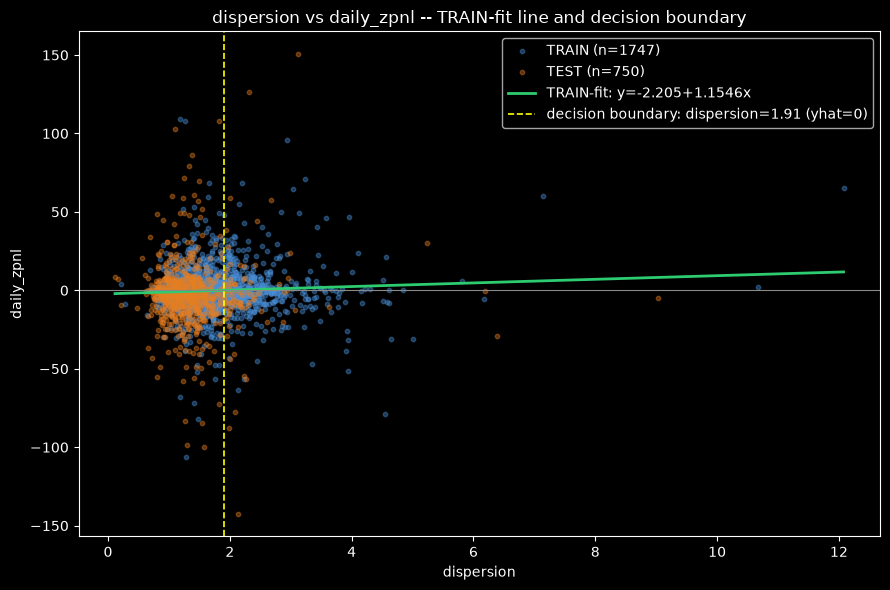

In [11]:
x_star = -b_tr / w_tr
pct_tr_above = (x_tr > x_star).mean()
pct_te_above = (yhat_te > 0).mean()
print(f'x* = -b/w = {x_star:.4f}')
print(f'% TRAIN days above x*: {pct_tr_above:.1%}    % TEST days above x*: {pct_te_above:.1%}')

traded = test[yhat_te > 0]
perday_traded = traded['daily_zpnl'].mean()
perday_baseline = test['daily_zpnl'].mean()
zpf_traded, zpf_base = zpf(traded['daily_zpnl']), zpf(test['daily_zpnl'])
print(f'\nTEST traded:   n={len(traded)}  ZPF={zpf_traded:.3f}  net={traded["daily_zpnl"].sum():.0f}  per-day={perday_traded:.4f}')
print(f'TEST baseline: n={n_test}  ZPF={zpf_base:.3f}  net={test["daily_zpnl"].sum():.0f}  per-day={perday_baseline:.4f}')

chk('x*', x_star, 1.9094, 5e-5)
assert round(pct_tr_above, 3) == 0.299 and round(pct_te_above, 3) == 0.115, '55a MISMATCH on % above x*'
assert len(traded) == 86, f'55a MISMATCH: TEST traded n={len(traded)}, expected 86'
chk('TEST traded ZPF', zpf_traded, 0.753, 5e-4)
chk('TEST traded per-day', perday_traded, -2.7243, 5e-5)
chk('TEST baseline per-day', perday_baseline, -2.9135, 5e-5)
assert round(traded['daily_zpnl'].sum()) == -234, '55a MISMATCH on TEST traded net'

fig, ax = plt.subplots(1, 1, figsize=(9, 6))
ax.scatter(x_tr, y_tr, s=10, alpha=0.4, color='#4a90d9', label=f'TRAIN (n={n_train})')
ax.scatter(x_te, y_te, s=10, alpha=0.4, color='#e67e22', label=f'TEST (n={n_test})')
xline = np.linspace(daily[FEATURE].min(), daily[FEATURE].max(), 100)
ax.plot(xline, b_tr + w_tr * xline, color='#2ecc71', linewidth=2, label=f'TRAIN-fit: y={b_tr:.3f}+{w_tr:.4f}x')
ax.axhline(0, color='#888', linewidth=0.8)
ax.axvline(x_star, color='yellow', linewidth=1.2, linestyle='--',
           label=f'decision boundary: dispersion={x_star:.2f} (yhat=0)')
ax.set_xlabel(FEATURE); ax.set_ylabel('daily_zpnl')
ax.set_title(f'{FEATURE} vs daily_zpnl -- TRAIN-fit line and decision boundary')
ax.legend()
plt.tight_layout()
plt.show()


## Step 11 — Ridge grid (TRAIN)

Minimise Σ(y − b − w·x)² + λ·w²  (intercept unpenalised) →  w_ridge = Sxy / (Sxx + λ),
b_ridge = ȳ − w_ridge·x̄.  λ is scanned as multiples of Sxx: λ/Sxx ∈ {0, 0.01, 0.05, 0.1, 0.25, 0.5, 1, 2}.
Each row is cross-checked against `sklearn.linear_model.Ridge`.

Plain English: shrink w toward 0 by a controlled amount; bigger λ = flatter line. λ=0 is plain OLS.
**Sample: TRAIN.**

In [12]:
from sklearn.linear_model import Ridge

LAMBDA_FRACS = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 1, 2]
rows = []
for frac in LAMBDA_FRACS:
    lam = frac * Sxx_tr
    w_r = Sxy_tr / (Sxx_tr + lam)
    b_r = y_tr.mean() - w_r * x_tr.mean()
    sk = Ridge(alpha=lam, fit_intercept=True).fit(x_tr.reshape(-1, 1), y_tr)
    rows.append(dict(lambda_frac=frac, lam=round(lam, 2), w_ridge=round(w_r, 6), w_sklearn=round(sk.coef_[0], 6),
                     b_ridge=round(b_r, 4), b_sklearn=round(sk.intercept_, 4),
                     x_star=round(-b_r / w_r, 4), pct_train_positive=round((b_r + w_r * x_tr > 0).mean(), 4)))
ridge_df = pd.DataFrame(rows)
print(ridge_df.to_string(index=False))
max_mismatch = max(abs(r['w_ridge'] - r['w_sklearn']) for r in rows)
print(f'\nmax |by-hand w - sklearn w| = {max_mismatch:.2e}')
assert max_mismatch < 1e-6
print('Larger lambda -> fewer positive-predicted TRAIN days (monotonic):',
      all(ridge_df['pct_train_positive'].diff().dropna() <= 1e-9))


 lambda_frac     lam  w_ridge  w_sklearn  b_ridge  b_sklearn  x_star  pct_train_positive
        0.00    0.00 1.154600   1.154600  -2.2046    -2.2046  1.9094              0.2988
        0.01    9.06 1.143169   1.143169  -2.1845    -2.1845  1.9109              0.2982
        0.05   45.31 1.099619   1.099619  -2.1078    -2.1078  1.9168              0.2936
        0.10   90.62 1.049637   1.049637  -2.0198    -2.0198  1.9242              0.2902
        0.25  226.54 0.923680   0.923680  -1.7979    -1.7979  1.9465              0.2765
        0.50  453.08 0.769734   0.769734  -1.5268    -1.5268  1.9836              0.2564
        1.00  906.16 0.577300   0.577300  -1.1880    -1.1880  2.0578              0.2267
        2.00 1812.31 0.384867   0.384867  -0.8491    -0.8491  2.2062              0.1712

max |by-hand w - sklearn w| = 0.00e+00
Larger lambda -> fewer positive-predicted TRAIN days (monotonic): True


## Step 12 — Chronological CV on TRAIN, pick λ, final TEST evaluation

`TimeSeriesSplit(n_splits=5)` (expanding window) on TRAIN only: for each λ, fit on the earlier part
of TRAIN, score MSE on the next block; λ with the lowest mean MSE wins. Then refit on all of TRAIN with
that λ and evaluate **once** on TEST.

Plain English: let the data (not us) decide how much shrinkage helps, using only TRAIN, in time order.
**Samples: λ chosen on TRAIN (CV); final evaluation on TEST.**

In [13]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_mse = {frac: [] for frac in LAMBDA_FRACS}
for frac in LAMBDA_FRACS:
    lam = frac * Sxx_tr
    for tr_i, va_i in tscv.split(x_tr):
        xf, yf = x_tr[tr_i], y_tr[tr_i]
        Sxx_f = np.sum((xf - xf.mean())**2)
        Sxy_f = np.sum((xf - xf.mean()) * (yf - yf.mean()))
        w_f = Sxy_f / (Sxx_f + lam)
        b_f = yf.mean() - w_f * xf.mean()
        cv_mse[frac].append(np.mean((y_tr[va_i] - (b_f + w_f * x_tr[va_i]))**2))

print(f'{"lambda/Sxx":>12}' + ''.join(f'{"fold"+str(i+1):>10}' for i in range(5)) + f'{"mean MSE":>12}')
for frac in LAMBDA_FRACS:
    print(f'{frac:>12}' + ''.join(f'{v:>10.2f}' for v in cv_mse[frac]) + f'{np.mean(cv_mse[frac]):>12.4f}')
mean_mses = {f: np.mean(v) for f, v in cv_mse.items()}
best_frac = min(mean_mses, key=mean_mses.get)
best_lambda = best_frac * Sxx_tr
print(f'\nChosen lambda/Sxx = {best_frac}  (lambda={best_lambda:.2f})')
assert best_frac == 0, f'55a MISMATCH: chosen lambda/Sxx={best_frac}, expected 0'

w_final = Sxy_tr / (Sxx_tr + best_lambda)
b_final = y_tr.mean() - w_final * x_tr.mean()
yhat_te_final = b_final + w_final * x_te
R2_oos_final = 1 - np.sum((y_te - yhat_te_final)**2) / SST_te_trainmean
traded_final = test[yhat_te_final > 0]
perday_traded_final = traded_final['daily_zpnl'].mean() if len(traded_final) else np.nan
zpf_final = zpf(traded_final['daily_zpnl'])
print(f'\nFinal TEST (lambda={best_lambda:.2f}): OOS R^2={R2_oos_final:.6f}  traded n={len(traded_final)}  '
      f'ZPF={zpf_final:.3f}  net={traded_final["daily_zpnl"].sum():.0f}  per-day={perday_traded_final:.4f}')
chk('final OOS R2', R2_oos_final, 0.004190, 5e-7)
assert len(traded_final) == 86


  lambda/Sxx     fold1     fold2     fold3     fold4     fold5    mean MSE
           0     34.32     98.69    287.95    348.33    321.71    218.1966
        0.01     34.30     98.70    288.01    348.31    321.70    218.2018
        0.05     34.26     98.73    288.25    348.24    321.66    218.2256
         0.1     34.23     98.76    288.49    348.16    321.62    218.2548
        0.25     34.22     98.83    289.02    348.00    321.54    218.3225
         0.5     34.21     98.88    289.53    347.85    321.47    218.3906
           1     34.22     98.92    290.03    347.72    321.42    218.4609
           2     34.22     98.95    290.40    347.64    321.40    218.5232

Chosen lambda/Sxx = 0  (lambda=0.00)

Final TEST (lambda=0.00): OOS R^2=0.004190  traded n=86  ZPF=0.753  net=-234  per-day=-2.7243
  [assert OK vs 55a] final OOS R2 = 0.004190


# Gate summary and verdict

- **A** — OOS R² > 0 (TEST, chosen-λ model; λ=0 here so same as OLS)
- **B** — textbook p < 0.05 (TRAIN)
- **C** — circular-shift p < 0.05 (TRAIN; the max-of-13 ceiling is information only)
- **D** — TEST traded-days ZPF > 1.0 **and** per-day average beats the all-TEST baseline

4/4 → KEEP · 2-3 → NEEDS-MORE-WORK · 0-1 → REJECT.
Caveat: this 4-gate bar is more lenient than `#54`'s max-of-13 discipline; it does not overturn
`#54`'s RULED OUT verdict for dispersion.

In [14]:
gate_A = R2_oos_final > 0
gate_B = p_textbook < 0.05
gate_C = emp_p < 0.05
gate_D = (zpf_final > 1.0) and (perday_traded_final > perday_baseline)

gate_df = pd.DataFrame([
    ('A', 'OOS R^2 > 0', f'{R2_oos_final:.6f}', 'TEST', 'PASS' if gate_A else 'FAIL'),
    ('B', 'textbook p < 0.05', f'{p_textbook:.6f}', 'TRAIN', 'PASS' if gate_B else 'FAIL'),
    ('C', 'circular-shift p < 0.05', f'{emp_p:.6f}', 'TRAIN', 'PASS' if gate_C else 'FAIL'),
    ('D', 'TEST traded ZPF > 1.0 and per-day > baseline',
     f'ZPF {zpf_final:.3f}; per-day {perday_traded_final:.4f} vs {perday_baseline:.4f}', 'TEST', 'PASS' if gate_D else 'FAIL'),
], columns=['gate', 'condition', 'value', 'sample', 'result'])
print(gate_df.to_string(index=False))

n_pass = sum([gate_A, gate_B, gate_C, gate_D])
verdict = 'KEEP' if n_pass == 4 else ('NEEDS-MORE-WORK' if n_pass >= 2 else 'REJECT')
print(f'\nGates passed: {n_pass}/4   VERDICT: {verdict}')
assert (gate_A, gate_B, gate_C, gate_D) == (True, True, True, False) and verdict == 'NEEDS-MORE-WORK', \
    '55a MISMATCH: expected A/B/C PASS, D FAIL, NEEDS-MORE-WORK'
print('All 55b numbers and the verdict match 55a Sections 9-13.')


gate                                    condition                                 value sample result
   A                                  OOS R^2 > 0                              0.004190   TEST   PASS
   B                            textbook p < 0.05                              0.012836  TRAIN   PASS
   C                      circular-shift p < 0.05                              0.010882  TRAIN   PASS
   D TEST traded ZPF > 1.0 and per-day > baseline ZPF 0.753; per-day -2.7243 vs -2.9135   TEST   FAIL

Gates passed: 3/4   VERDICT: NEEDS-MORE-WORK
All 55b numbers and the verdict match 55a Sections 9-13.
